In [1]:
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
glob('/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/*/*.wav')

['/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP3.wav_1.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP3.wav_5001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP3.wav_10001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP3.wav_15001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP3.wav_20001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP3.wav_25001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP5.wav_1.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP5.wav_5001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP5.wav_10001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP5.wav_15001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP5.wav_20001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP5.wav_25001.wav',
 '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP5.wav_30001.wav',
 '/content/drive/MyDri

In [ ]:
audio_files = glob('/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/*/*.wav')

In [ ]:
print(audio_files[0])

/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Airplane/AP3.wav_1.wav


In [ ]:
#load audio files with librosa
signal, sr = librosa.load(audio_files[0])

In [ ]:
print(signal)

[0.         0.         0.         ... 0.53805053 0.5748667  0.61046684]


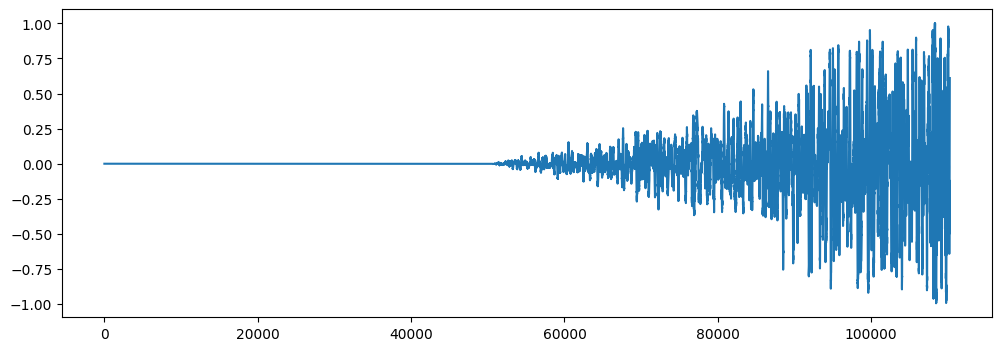

In [ ]:
import matplotlib.pyplot as plt
# Original audio with 1 channel
plt.figure(figsize=(12, 4))
plt.plot(signal)

In [ ]:
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(audio_files[0])

In [ ]:
wave_audio

array([[    0,     0],
       [    0,     0],
       [    0,     0],
       ...,
       [26384, 12459],
       [25476, 12515],
       [24310, 12414]], dtype=int16)

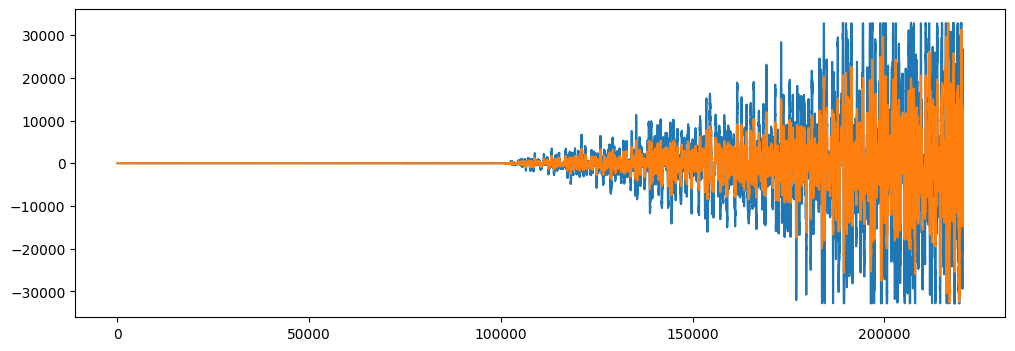

In [ ]:
import matplotlib.pyplot as plt

# Original audio with 2 channels
plt.figure(figsize=(12, 4))
plt.plot(wave_audio)

In [ ]:
mfccs = librosa.feature.mfcc(y=signal, n_mfcc=13, sr=sr)

In [ ]:
mfccs.shape

(13, 216)

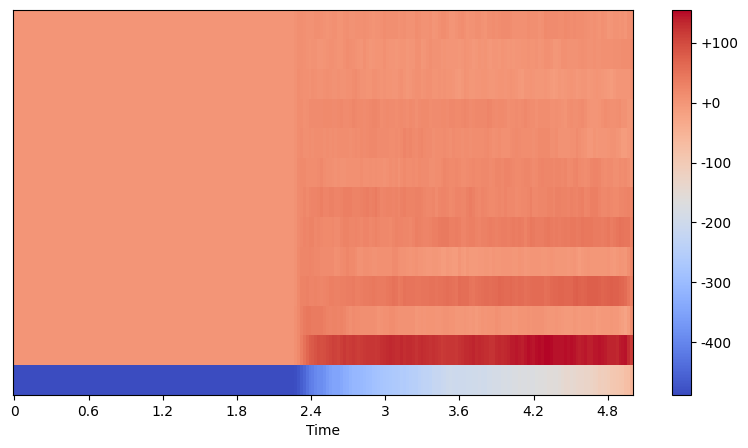

In [ ]:
plt.figure(figsize=(10, 5))
librosa.display.specshow(mfccs,
                         x_axis="time",
                         sr=sr)
plt.colorbar(format="%+2.f")
plt.show()

In [ ]:
delta_mfccs = librosa.feature.delta(mfccs)

In [ ]:
delta2_mfccs = librosa.feature.delta(mfccs, order=2)

In [ ]:
delta_mfccs.shape

(13, 216)

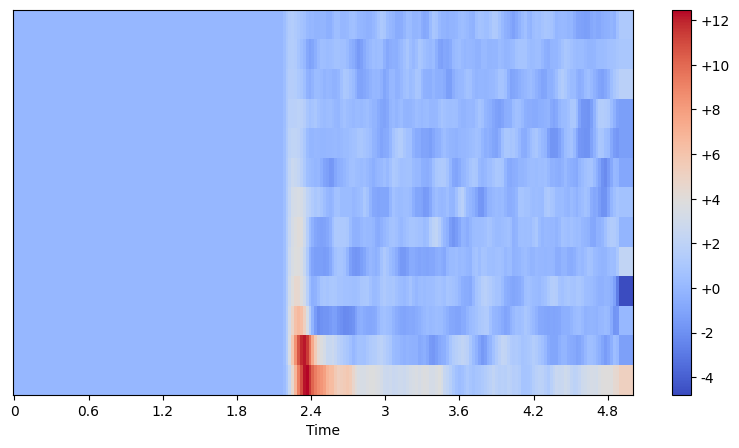

In [ ]:
plt.figure(figsize=(10, 5))
librosa.display.specshow(delta_mfccs,
                         x_axis="time",
                         sr=sr)
plt.colorbar(format="%+2.f")
plt.show()

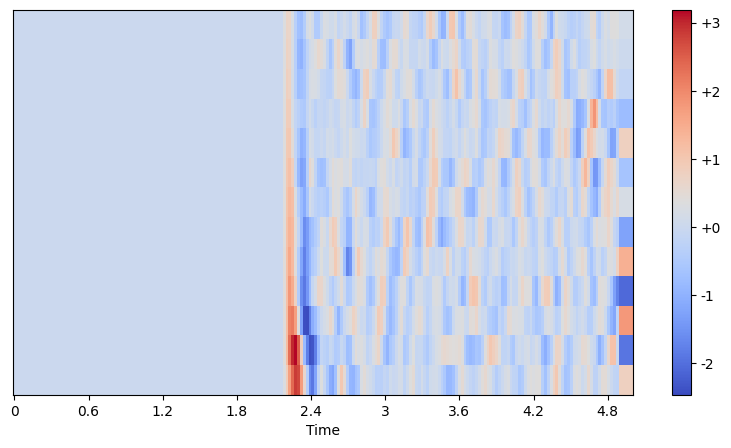

In [ ]:
plt.figure(figsize=(10, 5))
librosa.display.specshow(delta2_mfccs,
                         x_axis="time",
                         sr=sr)
plt.colorbar(format="%+2.f")
plt.show()

In [ ]:
mfccs_features = np.concatenate((mfccs, delta_mfccs, delta2_mfccs))

In [ ]:
mfccs_features.shape

(39, 216)

In [ ]:
mfccs_features


array([[-4.87613251e+02, -4.87613251e+02, -4.87613251e+02, ...,
        -7.50028381e+01, -7.18414230e+01, -5.47124939e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.45018906e+02,  1.31271759e+02,  1.14915344e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -2.16777153e+01, -9.42146301e+00,  1.15138149e+01],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.45563751e-01, -1.45563751e-01, -1.45563751e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.70419533e-02,  1.70419533e-02,  1.70419533e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.27516612e-01,  1.27516612e-01,  1.27516612e-01]], dtype=float32)

In [ ]:
import librosa
import numpy as np
import os
import csv

ip = "/content/drive/MyDrive/AUDIO_DATASETS/MFCC__OUTPUT/Washing machine/"
op = "/content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing machine/"

lst = os.listdir(ip)

for nm in lst:
    if nm.endswith('.wav'):
        print(str(ip) + "======>" + nm)
        sig, fs = librosa.load((ip + nm))
        mfccs = librosa.feature.mfcc(y=sig, sr=fs, n_mfcc=13)

        # Create the output folder if it does not exist
        os.makedirs(op, exist_ok=True)

        # Create the CSV file path
        csv_file_path = os.path.join(op, nm[:-4] + ".csv")

        # Write the MFCC features to the CSV file
        header = ['mfcc' + str(i) for i in range(1, 14)]
        with open(csv_file_path, 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(header)
            writer.writerows(mfccs.T)

        print(csv_file_path)


/content/drive/MyDrive/AUDIO_DATASETS/MFCC__OUTPUT/Washing machine/======>WM1.wav_1145001.wav
/content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing machine/WM1.wav_1145001.csv
/content/drive/MyDrive/AUDIO_DATASETS/MFCC__OUTPUT/Washing machine/======>WM1.wav_1150001.wav
/content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing machine/WM1.wav_1150001.csv
/content/drive/MyDrive/AUDIO_DATASETS/MFCC__OUTPUT/Washing machine/======>WM1.wav_1155001.wav
/content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing machine/WM1.wav_1155001.csv
/content/drive/MyDrive/AUDIO_DATASETS/MFCC__OUTPUT/Washing machine/======>WM1.wav_1160001.wav
/content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing machine/WM1.wav_1160001.csv
/content/drive/MyDrive/AUDIO_DATASETS/MFCC__OUTPUT/Washing machine/======>WM1.wav_1165001.wav
/content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing machine/WM1.wav_1165001.csv
/content/drive/MyDrive/AUDIO_DATASETS/MFCC__OUTPUT/Washing machine/======>WM1.wav_1170001.wav
/content/drive/MyDrive/AUDIO_DATASETS/MFC

In [ ]:
# import librosa

# def open_file(file_path):
#     signal, sr = librosa.load(file_path, sr=None)
#     return signal, sr

In [ ]:
# import numpy as np
# import librosa
# import os

# def open_file(file_path):
#     signal, sr = librosa.load(file_path, sr=None)
#     return signal, sr

# def features_extractor(file_path):
#     signal, sr = open_file(file_path)
#     mfccs_features = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
#     mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)

#     return mfccs_scaled_features

# audio_files_path = '/content/drive/MyDrive/AUDIO_DATASETS/OUTPUT/Washing machine'
# all_features = []

# for file_name in os.listdir(audio_files_path):
#     file_path = os.path.join(audio_files_path, file_name)
#     features = features_extractor(file_path)
#     all_features.append(features)

In [ ]:
# data = np.vstack(all_features)

In [ ]:
# import pandas as pd
# n_mfcc=13
# df = pd.DataFrame(data)
# mfcc_features_path = '/content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing_machine.csv'
# header = ['mfcc'+ str(i) for i in range(1, n_mfcc+1)]
# df.to_csv(mfcc_features_path, index=False, header=header)

TO CREATE A NEW BLANK CSV IN DRIVE

In [ ]:
#TO CREATE A NEW BLANK CSV IN DRIVE

#import io

# Set the file path
#file_path = '/content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing_machine.csv'

# Create a new blank CSV file
#with io.open(file_path, 'w', newline='') as file:
    #file.write('')

#print(f'Blank CSV file created at {file_path}')

Blank CSV file created at /content/drive/MyDrive/AUDIO_DATASETS/MFCC/Washing_machine.csv
